## Evaluation of Texture-Shape Bias Experiment

#### Import packages

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams.update({
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"], 
})

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

#### Configuration
Set the input folder containing the CSV files and the output folder for figures/tables.

In [2]:
# ==== EDIT THESE PATHS ====
INPUT_DIR = Path('/data/local/rgaisina/experiments_final/eval_results')
OUTPUT_DIR = Path('/data/local/rgaisina/experiments_final/eval_results_1')
FIGURES_DIR = OUTPUT_DIR / 'figures'
TABLES_DIR = OUTPUT_DIR / 'tables'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print('Input dir :', INPUT_DIR)
print('Output dir:', OUTPUT_DIR)

Input dir : /data/local/rgaisina/experiments_final/eval_results
Output dir: /data/local/rgaisina/experiments_final/eval_results_1


#### Shared constants

In [3]:
MODEL_ORDER = ['resnet18', 'resnet50', 'vit_tiny', 'vit_base']
MODEL_DISPLAY = {
    'resnet18': 'ResNet18',
    'resnet50': 'ResNet50',
    'vit_tiny': 'ViT Tiny',
    'vit_base': 'ViT Base',
}
FAMILY_DISPLAY = {
    'resnet18': 'CNN',
    'resnet50': 'CNN',
    'vit_tiny': 'ViT',
    'vit_base': 'ViT',
}
CONDITION_ORDER = [
    'original',
    'texture_only',
    'texture_plus_edges',
    'texture_adain',
    'texture_nst',
]
CONDITION_DISPLAY = {
    'original': 'Original',
    'texture_only': 'Texture Only',
    'texture_plus_edges': 'Texture + Edges',
    'texture_adain': 'Texture AdaIN',
    'texture_nst': 'Texture NST',
}
DECISION_ORDER = ['shape', 'texture', 'other']

#### Helper functions

In [4]:
def parse_model_from_name(name: str) -> str:
    if 'resnet18' in name:
        return 'resnet18'
    if 'resnet50' in name:
        return 'resnet50'
    if 'vit_tiny' in name:
        return 'vit_tiny'
    if 'vit_base' in name:
        return 'vit_base'
    raise ValueError(f'Could not parse model from filename: {name}')


def parse_condition_from_name(name: str) -> str:
    if 'eval_original_' in name:
        return 'original'
    if 'texture_plus_edges' in name:
        return 'texture_plus_edges'
    if 'texture_only' in name:
        return 'texture_only'
    if 'texture_adain' in name:
        return 'texture_adain'
    if 'texture_nst_content' in name:
        return 'texture_nst'
    raise ValueError(f'Could not parse condition from filename: {name}')


def shape_bias_from_decisions(series: pd.Series) -> float:
    counts = series.value_counts()
    shape_n = int(counts.get('shape', 0))
    texture_n = int(counts.get('texture', 0))
    denom = shape_n + texture_n
    return float(shape_n / denom) if denom > 0 else np.nan

def safe_mean_bool(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors='coerce')
    return float(s.mean()) if len(s) else np.nan


def grouped_bar_positions(n_groups: int, n_bars: int, width: float = 0.18):
    x = np.arange(n_groups)
    offsets = (np.arange(n_bars) - (n_bars - 1) / 2.0) * width
    return x, offsets


def save_figure(fig, filename: str, subdir: Path = FIGURES_DIR, tight=True):
    subdir.mkdir(parents=True, exist_ok=True)
    path = subdir / filename
    if tight:
        fig.savefig(path, bbox_inches='tight')
    else:
        fig.savefig(path)
    print(f'Saved: {path}')
    return path


def annotate_bars(ax, fmt='{:.2f}', fontsize=9, y_offset=0.01):
    y_min, y_max = ax.get_ylim()
    y_span = y_max - y_min
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if np.isnan(height):
                continue
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + y_offset * y_span,
                fmt.format(height),
                ha='center',
                va='bottom',
                fontsize=fontsize,
                clip_on=False,
            )


def annotate_stacked_bars(ax, fontsize=9, fmt='{:.2f}', min_height=0.04):
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if np.isnan(height) or height < min_height:
                continue
            x = bar.get_x() + bar.get_width() / 2
            y = bar.get_y() + height / 2
            ax.text(x, y, fmt.format(height), ha='center', va='center', fontsize=fontsize)


def heatmap_with_values(
    data: pd.DataFrame,
    title: str,
    figsize=(8, 6),
    vmin=None,
    vmax=None,
    cmap='viridis',
    value_fmt='.2f',
    rotate_x=25,
):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data.values, aspect='auto', vmin=vmin, vmax=vmax, cmap=cmap)

    ax.set_xticks(np.arange(len(data.columns)))
    ax.set_xticklabels(list(data.columns), rotation=rotate_x, ha='right')
    ax.set_yticks(np.arange(len(data.index)))
    ax.set_yticklabels(list(data.index))
    ax.set_title(title, pad=14)

    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('Value', rotation=270, labelpad=16)

    finite_vals = data.values[np.isfinite(data.values)] if data.size else np.array([])
    threshold = np.nanmean(finite_vals) if finite_vals.size else 0.5
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.iloc[i, j]
            if pd.isna(val):
                continue
            color = 'white' if val >= threshold else 'black'
            ax.text(j, i, format(val, value_fmt), ha='center', va='center', color=color, fontsize=8)

    fig.tight_layout()
    return fig, ax


def set_clean_title_and_legend(fig, title, legend_handles_labels=None, legend_ncol=4, top=0.88):
    fig.suptitle(title, y=0.98, fontsize=14)
    fig.subplots_adjust(top=top)
    if legend_handles_labels is not None:
        handles, labels = legend_handles_labels
        fig.legend(
            handles,
            labels,
            loc='upper center',
            bbox_to_anchor=(0.5, 0.94),
            ncol=legend_ncol,
            frameon=False,
        )

#### Load all CSV files

In [5]:
def load_all_csvs(input_dir: Path) -> pd.DataFrame:
    csv_files = sorted(input_dir.glob('*.csv'))
    if not csv_files:
        raise FileNotFoundError(f'No CSV files found in {input_dir}')

    frames = []
    for csv_path in csv_files:
        name = csv_path.name
        df = pd.read_csv(csv_path)
        df['source_file'] = name
        df['model'] = parse_model_from_name(name)
        df['condition'] = parse_condition_from_name(name)
        df['model_display'] = df['model'].map(MODEL_DISPLAY)
        df['family'] = df['model'].map(FAMILY_DISPLAY)
        df['condition_display'] = df['condition'].map(CONDITION_DISPLAY)

        numeric_cols = [
            'shape_in_top5',
            'texture_in_top5',
            'prob_shape',
            'prob_texture',
            'prob_top1',
            'logit_shape',
            'logit_texture',
            'top1_logit_minus_shape_logit',
            'top1_logit_minus_texture_logit',
            'parent_top1_match',
            'parent_top5_match',
            'parent_prob_mass',
        ]
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        for col in ['decision_top1', 'decision_top5']:
            if col in df.columns:
                df[col] = df[col].astype(str).str.strip().str.lower()

        for col in ['shape_parent', 'pred_parent']:
            if col in df.columns:
                df[col] = df[col].astype(str).str.strip()


        frames.append(df)

    data = pd.concat(frames, ignore_index=True)
    data['model'] = pd.Categorical(data['model'], categories=MODEL_ORDER, ordered=True)
    data['condition'] = pd.Categorical(data['condition'], categories=CONDITION_ORDER, ordered=True)
    return data


data = load_all_csvs(INPUT_DIR)
print(f"Loaded {len(data):,} rows from {data['source_file'].nunique()} CSV files")
display(data.head())

Loaded 12,096 rows from 20 CSV files


,mode,image_id,shape_name,shape_wnid,texture_name,texture_wnid,shape_parent,pred_parent,decision_top1,decision_top5,shape_in_top5,texture_in_top5,parent_top1_match,parent_top5_match,parent_prob_mass,pred_idx,pred_wnid,pred_label,shape_idx,texture_idx,logit_shape,logit_texture,prob_shape,prob_texture,prob_top1,top1_logit_minus_shape_logit,top1_logit_minus_texture_logit,img_path,source_file,model,condition,model_display,family,condition_display
0,geirhos,ILSVRC2012_val_00001368,hen_bird,n01514859,chain_mail,n03000247,bird,bird,shape,shape,1,0,1,1,0.979532,8,n01514859,hen,8,490,1.807452,-4.366651,0.862045,0.001795,0.862045,0.000000,6.174103,/data/local/rgaisina/experiments_final/geirhos...,eval_geirhos_texture_adain_resnet18_a1_in1k_to...,resnet18,texture_adain,ResNet18,CNN,Texture AdaIN
1,geirhos,ILSVRC2012_val_00001368,hen_bird,n01514859,peacock,n01806143,bird,bird,shape,both,1,1,1,1,0.969224,8,n01514859,hen,8,84,0.377959,-3.285799,0.506592,0.012987,0.506592,0.000000,3.663757,/data/local/rgaisina/experiments_final/geirhos...,eval_geirhos_texture_adain_resnet18_a1_in1k_to...,resnet18,texture_adain,ResNet18,CNN,Texture AdaIN
2,geirhos,ILSVRC2012_val_00001368,hen_bird,n01514859,tiger,n02129604,bird,cat,other,texture,0,1,0,1,0.196030,282,n02123159,tiger_cat,8,292,-4.991254,-2.601259,0.005979,0.065255,0.283939,3.860457,1.470462,/data/local/rgaisina/experiments_final/geirhos...,eval_geirhos_texture_adain_resnet18_a1_in1k_to...,resnet18,texture_adain,ResNet18,CNN,Texture AdaIN
3,geirhos,ILSVRC2012_val_00001368,hen_bird,n01514859,honeycomb,n03530642,bird,bird,shape,shape,1,0,1,1,0.380506,8,n01514859,hen,8,599,-1.354825,-4.053998,0.345930,0.023268,0.345930,0.000000,2.699173,/data/local/rgaisina/experiments_final/geirhos...,eval_geirhos_texture_adain_resnet18_a1_in1k_to...,resnet18,texture_adain,ResNet18,CNN,Texture AdaIN
4,geirhos,ILSVRC2012_val_00001368,hen_bird,n01514859,zebra,n02391049,bird,n02391049,texture,texture,0,1,0,1,0.063999,340,n02391049,zebra,8,340,-4.460437,-0.153831,0.005725,0.424726,0.424726,4.306607,0.000000,/data/local/rgaisina/experiments_final/geirhos...,eval_geirhos_texture_adain_resnet18_a1_in1k_to...,resnet18,texture_adain,ResNet18,CNN,Texture AdaIN


#### Build summary tables

In [6]:
def build_summary_tables(data: pd.DataFrame):
    cue = data[data['condition'] != 'original'].copy()
    orig = data[data['condition'] == 'original'].copy()

    has_parent = {'parent_top1_match', 'parent_top5_match', 'parent_prob_mass'}.issubset(data.columns)

    rows = []
    for (model, condition), group in cue.groupby(['model', 'condition'], observed=True):
        counts_top1 = group['decision_top1'].value_counts()
        counts_top5 = group['decision_top5'].value_counts() if 'decision_top5' in group.columns else pd.Series(dtype=int)
        n = len(group)
        row = {
            'model': model,
            'model_display': MODEL_DISPLAY[str(model)],
            'family': FAMILY_DISPLAY[str(model)],
            'condition': condition,
            'condition_display': CONDITION_DISPLAY[str(condition)],
            'n': n,
            'shape_top1_pct': int(counts_top1.get('shape', 0)) / n,
            'texture_top1_pct': int(counts_top1.get('texture', 0)) / n,
            'other_top1_pct': int(counts_top1.get('other', 0)) / n,
            'shape_top5_pct': int(counts_top5.get('shape', 0)) / n if n else np.nan,
            'texture_top5_pct': int(counts_top5.get('texture', 0)) / n if n else np.nan,
            'both_top5_pct': int(counts_top5.get('both', 0)) / n if n else np.nan,
            'other_top5_pct': int(counts_top5.get('other', 0)) / n if n else np.nan,
            'shape_bias_top1': shape_bias_from_decisions(group['decision_top1']),
            'shape_bias_top5': shape_bias_from_decisions(group['decision_top5']) if 'decision_top5' in group.columns else np.nan,
            'shape_in_top5_rate': safe_mean_bool(group['shape_in_top5']),
            'texture_in_top5_rate': safe_mean_bool(group['texture_in_top5']),
            'mean_prob_shape': group['prob_shape'].mean(),
            'mean_prob_texture': group['prob_texture'].mean(),
            'mean_prob_top1': group['prob_top1'].mean(),
            'mean_prob_gap_shape_minus_texture': (group['prob_shape'] - group['prob_texture']).mean(),
            'median_prob_gap_shape_minus_texture': (group['prob_shape'] - group['prob_texture']).median(),
            'mean_logit_gap_shape_minus_texture': (group['logit_shape'] - group['logit_texture']).mean(),
        }
        if has_parent:
            row.update({
                'parent_top1_match': safe_mean_bool(group['parent_top1_match']),
                'parent_top5_match': safe_mean_bool(group['parent_top5_match']),
                'parent_prob_mass': pd.to_numeric(group['parent_prob_mass'], errors='coerce').mean(),
            })
        rows.append(row)

    summary = pd.DataFrame(rows).sort_values(['model', 'condition']).reset_index(drop=True)

    baseline_rows = []
    for model, group in orig.groupby('model', observed=True):
        counts_top1 = group['decision_top1'].value_counts()
        counts_top5 = group['decision_top5'].value_counts() if 'decision_top5' in group.columns else pd.Series(dtype=int)
        n = len(group)
        row = {
            'model': model,
            'model_display': MODEL_DISPLAY[str(model)],
            'family': FAMILY_DISPLAY[str(model)],
            'n': n,
            'shape_top1_pct': int(counts_top1.get('shape', 0)) / n,
            'texture_top1_pct': int(counts_top1.get('texture', 0)) / n,
            'other_top1_pct': int(counts_top1.get('other', 0)) / n,
            'shape_top5_pct': int(counts_top5.get('shape', 0)) / n if n else np.nan,
            'texture_top5_pct': int(counts_top5.get('texture', 0)) / n if n else np.nan,
            'both_top5_pct': int(counts_top5.get('both', 0)) / n if n else np.nan,
            'other_top5_pct': int(counts_top5.get('other', 0)) / n if n else np.nan,
            'shape_bias_top1': shape_bias_from_decisions(group['decision_top1']),
            'shape_bias_top5': shape_bias_from_decisions(group['decision_top5']) if 'decision_top5' in group.columns else np.nan,
            'shape_in_top5_rate': safe_mean_bool(group['shape_in_top5']),
            'texture_in_top5_rate': safe_mean_bool(group['texture_in_top5']),
            'mean_prob_shape': group['prob_shape'].mean(),
            'mean_prob_texture': group['prob_texture'].mean(),
            'mean_prob_top1': group['prob_top1'].mean(),
            'mean_prob_gap_shape_minus_texture': (group['prob_shape'] - group['prob_texture']).mean(),
            'median_prob_gap_shape_minus_texture': (group['prob_shape'] - group['prob_texture']).median(),
            'mean_logit_gap_shape_minus_texture': (group['logit_shape'] - group['logit_texture']).mean(),
        }
        if has_parent:
            row.update({
                'parent_top1_match': safe_mean_bool(group['parent_top1_match']),
                'parent_top5_match': safe_mean_bool(group['parent_top5_match']),
                'parent_prob_mass': pd.to_numeric(group['parent_prob_mass'], errors='coerce').mean(),
            })
        baseline_rows.append(row)
    baseline_summary = pd.DataFrame(baseline_rows).sort_values(['model']).reset_index(drop=True)

    family_agg_cols = [
        'shape_bias_top1',
        'shape_bias_top5',
        'shape_in_top5_rate',
        'texture_in_top5_rate',
        'shape_top1_pct',
        'texture_top1_pct',
        'other_top1_pct',
        'mean_prob_shape',
        'mean_prob_texture',
        'mean_prob_gap_shape_minus_texture',
    ]
    if has_parent:
        family_agg_cols += ['parent_top1_match', 'parent_top5_match', 'parent_prob_mass']

    family_summary = (
        summary.groupby(['family', 'condition', 'condition_display'], observed=True)[family_agg_cols]
        .mean()
        .reset_index()
        .sort_values(['family', 'condition'])
    )

    class_rows = []
    for (model, condition, shape_name), group in cue.groupby(['model', 'condition', 'shape_name'], observed=True):
        row = {
            'model': model,
            'model_display': MODEL_DISPLAY[str(model)],
            'family': FAMILY_DISPLAY[str(model)],
            'condition': condition,
            'condition_display': CONDITION_DISPLAY[str(condition)],
            'shape_name': shape_name,
            'n': len(group),
            'shape_bias_top1': shape_bias_from_decisions(group['decision_top1']),
            'shape_top1_pct': (group['decision_top1'] == 'shape').mean(),
            'texture_top1_pct': (group['decision_top1'] == 'texture').mean(),
            'other_top1_pct': (group['decision_top1'] == 'other').mean(),
            'shape_in_top5_rate': safe_mean_bool(group['shape_in_top5']),
            'texture_in_top5_rate': safe_mean_bool(group['texture_in_top5']),
            'mean_prob_shape': group['prob_shape'].mean(),
            'mean_prob_texture': group['prob_texture'].mean(),
        }
        if has_parent:
            row.update({
                'parent_top1_match': safe_mean_bool(group['parent_top1_match']),
                'parent_top5_match': safe_mean_bool(group['parent_top5_match']),
                'parent_prob_mass': pd.to_numeric(group['parent_prob_mass'], errors='coerce').mean(),
                'shape_parent': group['shape_parent'].iloc[0] if 'shape_parent' in group.columns else np.nan,
            })
        class_rows.append(row)
    class_summary = pd.DataFrame(class_rows).sort_values(['model', 'condition', 'shape_name']).reset_index(drop=True)
    return summary, baseline_summary, family_summary, class_summary, has_parent


summary_main, summary_baseline, summary_family, summary_class, HAS_PARENT_METRICS = build_summary_tables(data)
print('Parent metrics available:', HAS_PARENT_METRICS)
display(summary_main)

Parent metrics available: True


,model,model_display,family,condition,condition_display,n,shape_top1_pct,texture_top1_pct,other_top1_pct,shape_top5_pct,texture_top5_pct,both_top5_pct,other_top5_pct,shape_bias_top1,shape_bias_top5,shape_in_top5_rate,texture_in_top5_rate,mean_prob_shape,mean_prob_texture,mean_prob_top1,mean_prob_gap_shape_minus_texture,median_prob_gap_shape_minus_texture,mean_logit_gap_shape_minus_texture,parent_top1_match,parent_top5_match,parent_prob_mass
0,resnet18,ResNet18,CNN,texture_adain,Texture AdaIN,720,0.168056,0.166667,0.665278,0.326389,0.240278,0.054167,0.379167,0.502075,0.575980,0.380556,0.294444,0.112387,0.105795,0.384455,0.006592,0.002625,0.976156,0.262500,0.462500,0.211069
1,resnet18,ResNet18,CNN,texture_nst,Texture NST,720,0.277778,0.193056,0.529167,0.423611,0.194444,0.130556,0.251389,0.589971,0.685393,0.554167,0.325000,0.201486,0.142267,0.488864,0.059218,0.012974,1.926184,0.377778,0.630556,0.315766
2,resnet18,ResNet18,CNN,texture_only,Texture Only,720,0.034722,0.798611,0.166667,0.052778,0.794444,0.069444,0.083333,0.041667,0.062295,0.122222,0.863889,0.022872,0.709212,0.774623,-0.686340,-0.950899,-8.846212,0.061111,0.193056,0.047641
3,resnet18,ResNet18,CNN,texture_plus_edges,Texture + Edges,720,0.209722,0.415278,0.375000,0.309722,0.423611,0.100000,0.166667,0.335556,0.422348,0.409722,0.523611,0.162756,0.342654,0.606904,-0.179898,-0.017292,-1.285440,0.286111,0.501389,0.243673
4,resnet50,ResNet50,CNN,texture_adain,Texture AdaIN,720,0.209722,0.104167,0.686111,0.372222,0.163889,0.040278,0.423611,0.668142,0.694301,0.412500,0.204167,0.160354,0.069939,0.482623,0.090415,0.004939,2.422895,0.305556,0.536111,0.253403
5,resnet50,ResNet50,CNN,texture_nst,Texture NST,720,0.309722,0.179167,0.511111,0.472222,0.193056,0.115278,0.219444,0.633523,0.709812,0.587500,0.308333,0.271047,0.146200,0.612552,0.124847,0.020006,2.958077,0.426389,0.669444,0.383932
6,resnet50,ResNet50,CNN,texture_only,Texture Only,720,0.061111,0.781944,0.156944,0.061111,0.762500,0.113889,0.062500,0.072488,0.074199,0.175000,0.876389,0.046753,0.742260,0.845120,-0.695507,-0.985753,-9.769651,0.077778,0.252778,0.067693
7,resnet50,ResNet50,CNN,texture_plus_edges,Texture + Edges,720,0.265278,0.448611,0.286111,0.347222,0.405556,0.130556,0.116667,0.371595,0.461255,0.477778,0.536111,0.227892,0.399098,0.733401,-0.171206,-0.020950,-1.201325,0.355556,0.572222,0.311734
8,vit_base,ViT Base,ViT,texture_adain,Texture AdaIN,720,0.343056,0.052778,0.604167,0.663889,0.063889,0.045833,0.226389,0.866667,0.912214,0.709722,0.109722,0.261773,0.034547,0.474331,0.227226,0.102121,5.324140,0.527778,0.791667,0.448336
9,vit_base,ViT Base,ViT,texture_nst,Texture NST,720,0.493056,0.120833,0.386111,0.706944,0.098611,0.111111,0.083333,0.803167,0.877586,0.818056,0.209722,0.385662,0.085914,0.591269,0.299748,0.254516,6.054270,0.656944,0.865278,0.572325


#### Save tables to disk

In [7]:
summary_main.to_csv(TABLES_DIR / 'summary_main.csv', index=False)
summary_baseline.to_csv(TABLES_DIR / 'summary_baseline.csv', index=False)
summary_family.to_csv(TABLES_DIR / 'summary_family.csv', index=False)
summary_class.to_csv(TABLES_DIR / 'summary_class.csv', index=False)

shape_bias_wide = summary_main.pivot(index='model_display', columns='condition_display', values='shape_bias_top1')
shape_bias_wide.to_csv(TABLES_DIR / 'shape_bias_wide.csv')

top5_wide = summary_main.pivot(index='model_display', columns='condition_display', values='shape_in_top5_rate')
top5_wide.to_csv(TABLES_DIR / 'top5_recovery_wide.csv')

print('Saved tables to:', TABLES_DIR)

Saved tables to: /data/local/rgaisina/experiments_final/eval_results_1/tables


#### Shape bias (top-1)

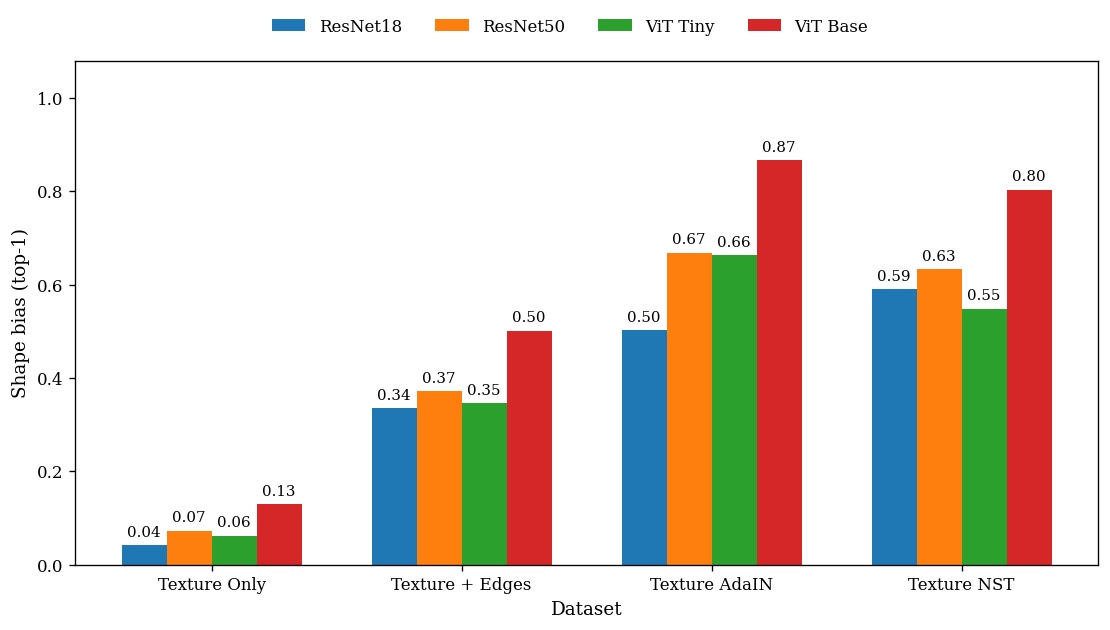

Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/figure_shape_bias_top1_annotated.png


PosixPath('/data/local/rgaisina/experiments_final/eval_results_1/figures/figure_shape_bias_top1_annotated.png')

In [8]:
conditions = [c for c in CONDITION_ORDER if c != 'original']

x, offsets = grouped_bar_positions(n_groups=len(conditions), n_bars=len(MODEL_ORDER), width=0.18)

fig, ax = plt.subplots(figsize=(11, 6))

for i, model in enumerate(MODEL_ORDER):
    subset = summary_main[summary_main['model'] == model].set_index('condition').reindex(conditions)
    y = subset['shape_bias_top1'].values
    
    ax.bar(x + offsets[i], y, width=0.18, label=MODEL_DISPLAY[model])

ax.set_xticks(x)
ax.set_xticklabels([CONDITION_DISPLAY[c] for c in conditions])

ax.set_ylabel('Shape bias (top-1)')
ax.set_xlabel('Dataset') 
ax.set_ylim(0, 1.08)
#ax.set_title('Shape bias across shape-texture conditions (top-1)', pad=14)

annotate_bars(ax, fmt='{:.2f}', fontsize=9, y_offset=0.012)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=4, frameon=False)

fig.subplots_adjust(top=0.84, bottom=0.14)

plt.show()
save_figure(fig, 'figure_shape_bias_top1_annotated.png')

#### Shape bias (top-5)

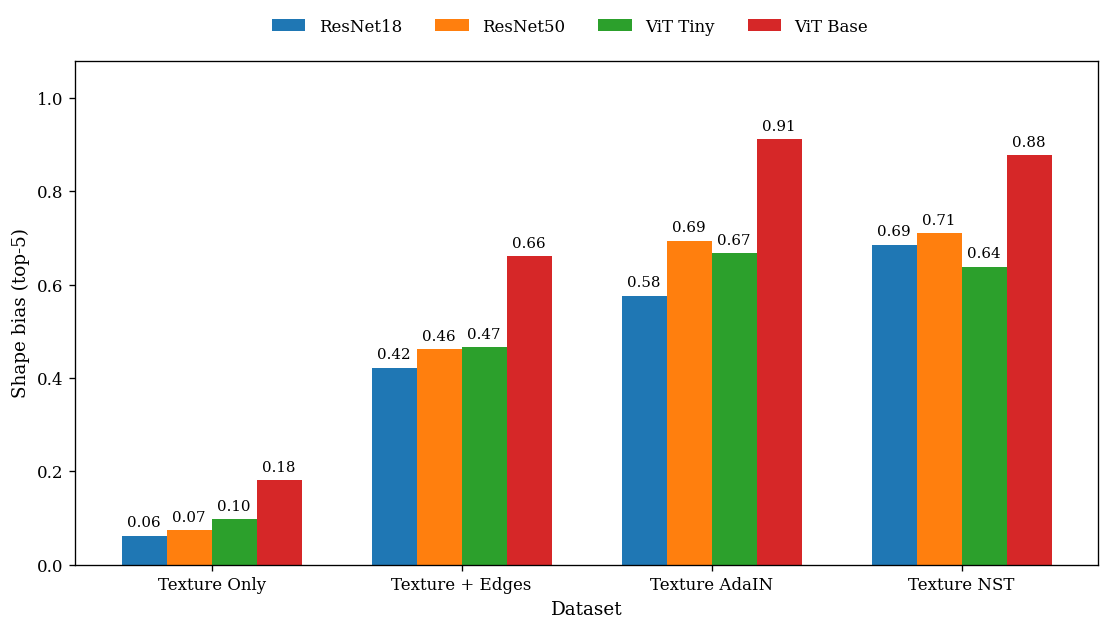

Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/figure_shape_bias_top5_annotated.png


PosixPath('/data/local/rgaisina/experiments_final/eval_results_1/figures/figure_shape_bias_top5_annotated.png')

In [9]:
conditions = [c for c in CONDITION_ORDER if c != 'original']

x, offsets = grouped_bar_positions(n_groups=len(conditions), n_bars=len(MODEL_ORDER), width=0.18)

fig, ax = plt.subplots(figsize=(11, 6))

for i, model in enumerate(MODEL_ORDER):
    subset = summary_main[summary_main['model'] == model].set_index('condition').reindex(conditions)
    y = subset['shape_bias_top5'].values
    
    ax.bar(x + offsets[i], y, width=0.18, label=MODEL_DISPLAY[model])

ax.set_xticks(x)
ax.set_xticklabels([CONDITION_DISPLAY[c] for c in conditions])

ax.set_ylabel('Shape bias (top-5)')
ax.set_xlabel('Dataset') 
ax.set_ylim(0, 1.08)
#ax.set_title('Shape bias across shape-texture conditions (top-5)', pad=14)

annotate_bars(ax, fmt='{:.2f}', fontsize=9, y_offset=0.012)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=4, frameon=False)

fig.subplots_adjust(top=0.84, bottom=0.14)

plt.show()
save_figure(fig, 'figure_shape_bias_top5_annotated.png')

#### Stacked shape-texture decision distribution

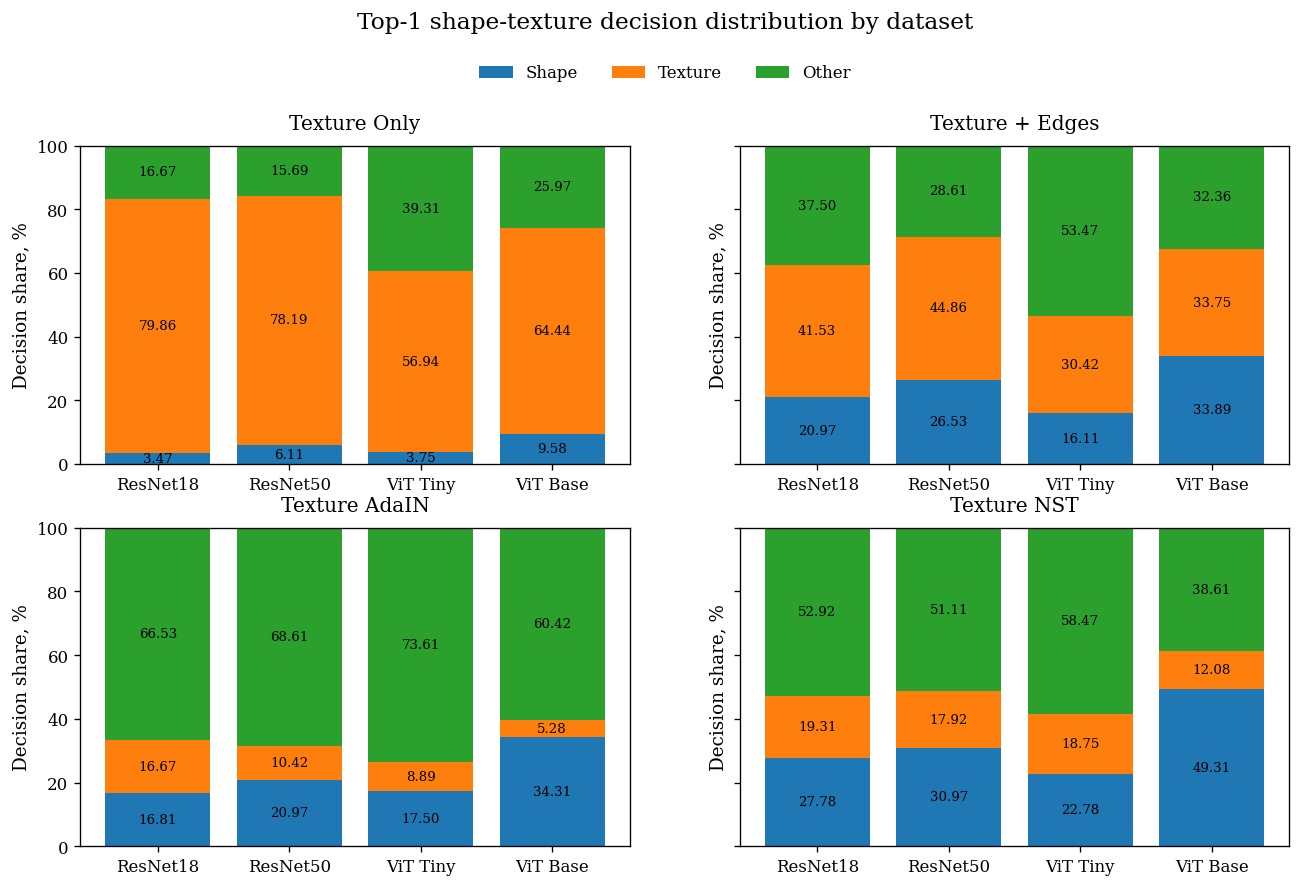

Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/figure_decision_distribution_stacked_annotated.png


PosixPath('/data/local/rgaisina/experiments_final/eval_results_1/figures/figure_decision_distribution_stacked_annotated.png')

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
axes = axes.flatten()

for ax, condition in zip(axes, conditions):
    subset = summary_main[summary_main['condition'] == condition].set_index('model').reindex(MODEL_ORDER)
    shape_vals = subset['shape_top1_pct'].values * 100
    texture_vals = subset['texture_top1_pct'].values * 100
    other_vals = subset['other_top1_pct'].values * 100
    x_local = np.arange(len(MODEL_ORDER))

    ax.bar(x_local, shape_vals, label='Shape')
    ax.bar(x_local, texture_vals, bottom=shape_vals, label='Texture')
    ax.bar(x_local, other_vals, bottom=shape_vals + texture_vals, label='Other')

    ax.set_xticks(x_local)
    ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODEL_ORDER], rotation=0)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Decision share, %')
    ax.set_title(CONDITION_DISPLAY[condition], pad=10)
    annotate_stacked_bars(ax, fontsize=8, fmt='{:.2f}', min_height=0.06)

handles, labels = axes[0].get_legend_handles_labels()
set_clean_title_and_legend(fig, 'Top-1 shape-texture decision distribution by dataset', legend_handles_labels=(handles, labels), legend_ncol=3, top=0.84)

plt.show()
save_figure(fig, 'figure_decision_distribution_stacked_annotated.png')

## Model family comparison

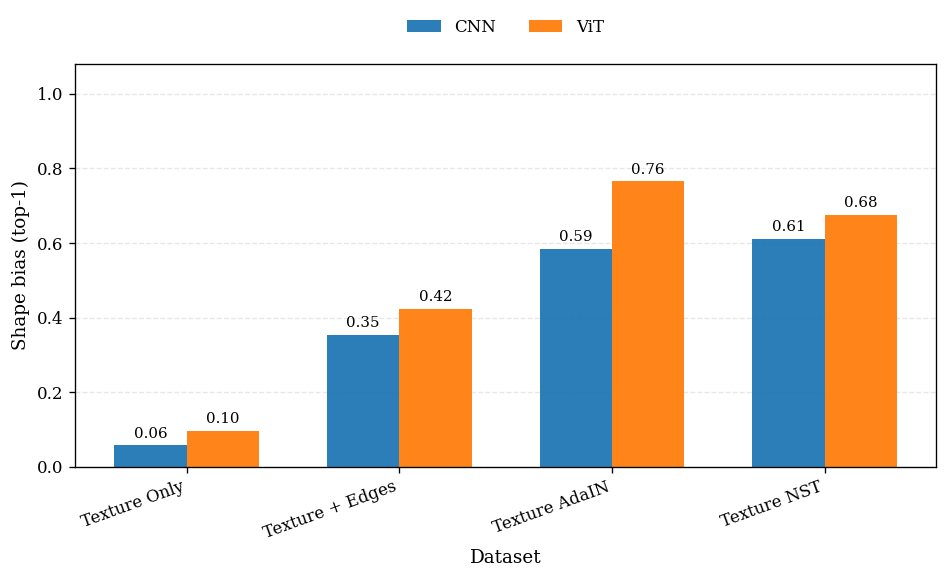

Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/figure_family_shape_bias_only.png


PosixPath('/data/local/rgaisina/experiments_final/eval_results_1/figures/figure_family_shape_bias_only.png')

In [11]:
families = ['CNN', 'ViT']
x_f = np.arange(len(conditions))
width = 0.34

fig, ax = plt.subplots(figsize=(8, 5))

for i, family in enumerate(families):
    subset = (
        summary_family[summary_family['family'] == family]
        .set_index('condition')
        .reindex(conditions)
    )
    
    ax.bar(
        x_f + (i - 0.5) * width,
        subset['shape_bias_top1'].values,
        width=width,
        label=family,
        edgecolor='none',
        alpha=0.95
    )

# Axis formatting
ax.set_xticks(x_f)
ax.set_xticklabels([CONDITION_DISPLAY[c] for c in conditions], rotation=20, ha='right')
ax.set_ylim(0, 1.08)
ax.set_ylabel('Shape bias (top-1)')
ax.set_xlabel('Dataset')
#ax.set_title('Model family comparison: shape bias', pad=12)

# Grid + clean style
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

annotate_bars(ax, fmt='{:.2f}', fontsize=9, y_offset=0.012)

# Legend (below title, centered)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

save_figure(fig, 'figure_family_shape_bias_only.png')

## 14. Parent semantic robustness

Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/parent_top1_match.png


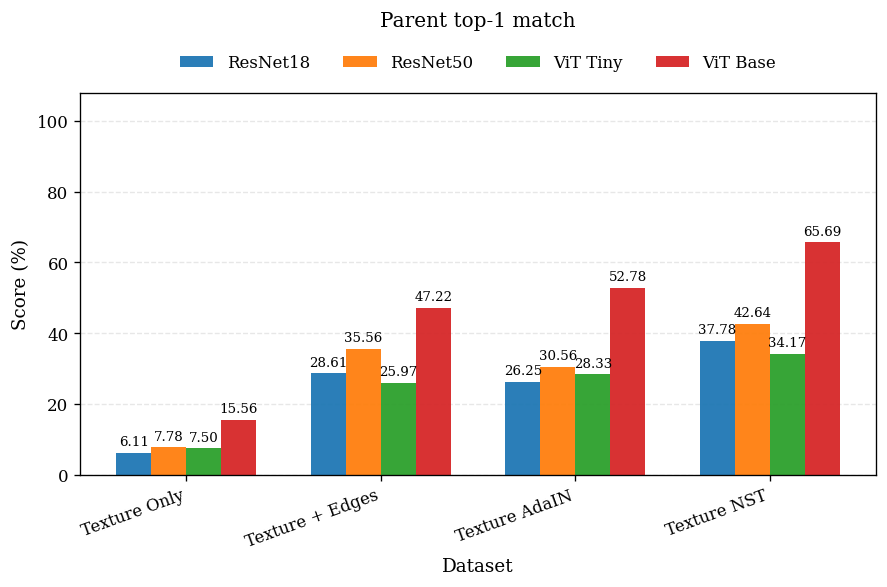

Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/parent_top5_match.png


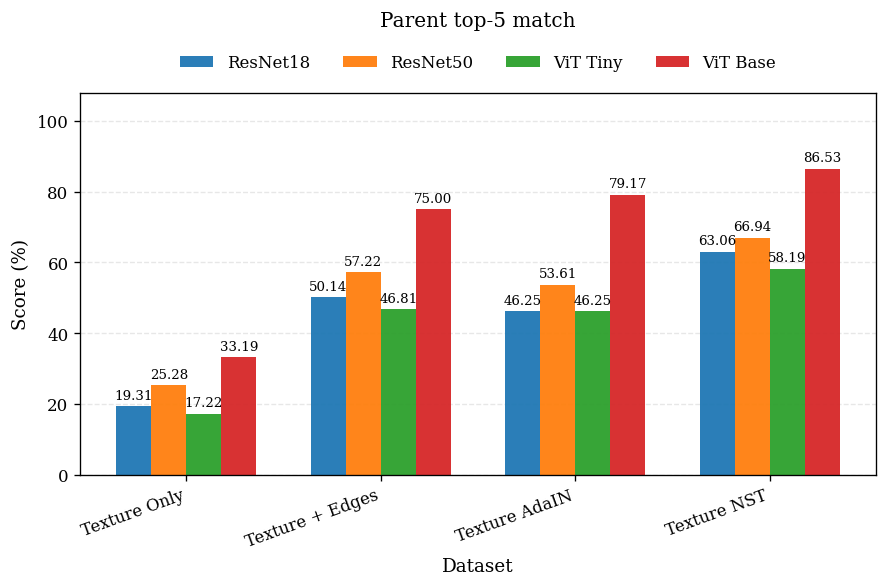

Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/parent_prob_mass.png


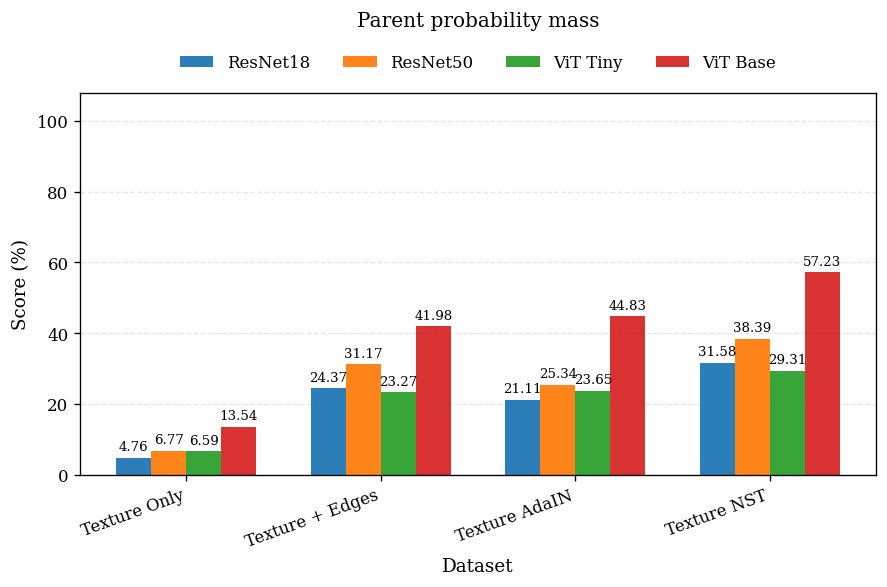

In [12]:
if not HAS_PARENT_METRICS:
    print('Parent metrics not found in the loaded CSV files.')
else:
    parent_metrics = [
        ('parent_top1_match', 'Parent top-1 match', (0, 108), 'parent_top1_match.png'),
        ('parent_top5_match', 'Parent top-5 match', (0, 108), 'parent_top5_match.png'),
        ('parent_prob_mass', 'Parent probability mass', (0, 108), 'parent_prob_mass.png'),
    ]

    x = np.arange(len(conditions))
    width = 0.18

    for metric, title, ylim, filename in parent_metrics:
        fig, ax = plt.subplots(figsize=(7.5, 5))

        for i, model in enumerate(MODEL_ORDER):
            subset = (
                summary_main[summary_main['model'] == model]
                .set_index('condition')
                .reindex(conditions)
            )
            ax.bar(
                x + (i - (len(MODEL_ORDER) - 1) / 2) * width,
                subset[metric].values * 100,
                width=width,
                label=MODEL_DISPLAY[model],
                edgecolor='none',
                alpha=0.95,
            )

        ax.set_xticks(x)
        ax.set_xticklabels([CONDITION_DISPLAY[c] for c in conditions], rotation=20, ha='right')
        ax.set_title(title, pad=40)
        ax.set_ylabel('Score (%)')
        ax.set_xlabel('Dataset')
        ax.set_ylim(*ylim)

        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_axisbelow(True)

        annotate_bars(ax, fmt='{:.2f}', fontsize=8, y_offset=0.012)

        ax.legend(
            loc='upper center',
            bbox_to_anchor=(0.5, 1.14),
            ncol=4,
            frameon=False
        )

        plt.tight_layout()
        save_figure(fig, filename)
        plt.show()

## 15. Parent robustness by family

Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/parent_semantic_family.png


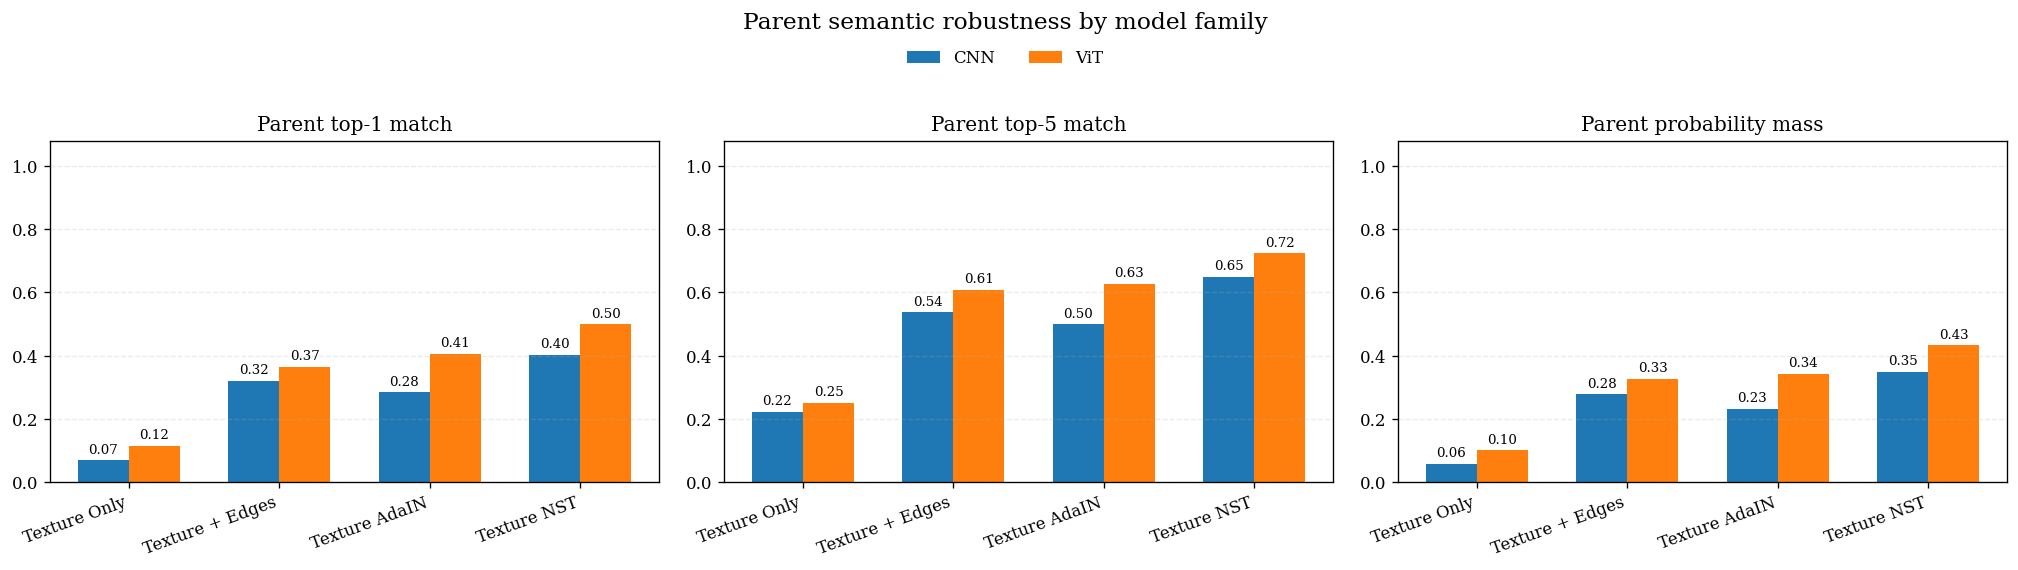

In [13]:
if not HAS_PARENT_METRICS:
    print('Parent metrics not found in the loaded CSV files.')
else:
    parent_family_metrics = [
        ('parent_top1_match', 'Parent top-1 match'),
        ('parent_top5_match', 'Parent top-5 match'),
        ('parent_prob_mass', 'Parent probability mass'),
    ]

    families = ['CNN', 'ViT']
    x_f = np.arange(len(conditions))
    width = 0.34

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharex=True)
    for ax, (metric, title) in zip(axes, parent_family_metrics):
        for i, family in enumerate(families):
            subset = summary_family[summary_family['family'] == family].set_index('condition').reindex(conditions)
            ax.bar(x_f + (i - 0.5) * width, subset[metric].values, width=width, label=family)
        ax.set_xticks(x_f)
        ax.set_xticklabels([CONDITION_DISPLAY[c] for c in conditions], rotation=20, ha='right')
        ax.set_title(title)
        ax.set_ylim(0, 1.08)
        ax.grid(axis='y', alpha=0.25)
        annotate_bars(ax, fmt='{:.2f}', fontsize=8, y_offset=0.012)

    handles, labels = axes[0].get_legend_handles_labels()
    set_clean_title_and_legend(fig, 'Parent semantic robustness by model family', (handles, labels), legend_ncol=2, top=0.82)
    fig.tight_layout(rect=(0, 0, 1, 0.9))
    save_figure(fig, 'parent_semantic_family.png')
    plt.show()

## 17. Parent metrics summary tables

In [14]:
if not HAS_PARENT_METRICS:
    print('Parent metrics not found in the loaded CSV files.')
else:
    parent_summary_table = (
        summary_main[
            ['model_display', 'condition_display', 'parent_top1_match', 'parent_top5_match', 'parent_prob_mass']
        ]
        .copy()
        .round(3)
    )
    display(parent_summary_table)
    parent_summary_table.to_csv(TABLES_DIR / 'parent_metrics_summary_table.csv', index=False)
    print('Saved parent metrics summary table')

,model_display,condition_display,parent_top1_match,parent_top5_match,parent_prob_mass
0,ResNet18,Texture AdaIN,0.262,0.462,0.211
1,ResNet18,Texture NST,0.378,0.631,0.316
2,ResNet18,Texture Only,0.061,0.193,0.048
3,ResNet18,Texture + Edges,0.286,0.501,0.244
4,ResNet50,Texture AdaIN,0.306,0.536,0.253
5,ResNet50,Texture NST,0.426,0.669,0.384
6,ResNet50,Texture Only,0.078,0.253,0.068
7,ResNet50,Texture + Edges,0.356,0.572,0.312
8,ViT Base,Texture AdaIN,0.528,0.792,0.448
9,ViT Base,Texture NST,0.657,0.865,0.572


Saved parent metrics summary table


## 18. Class heatmap with values

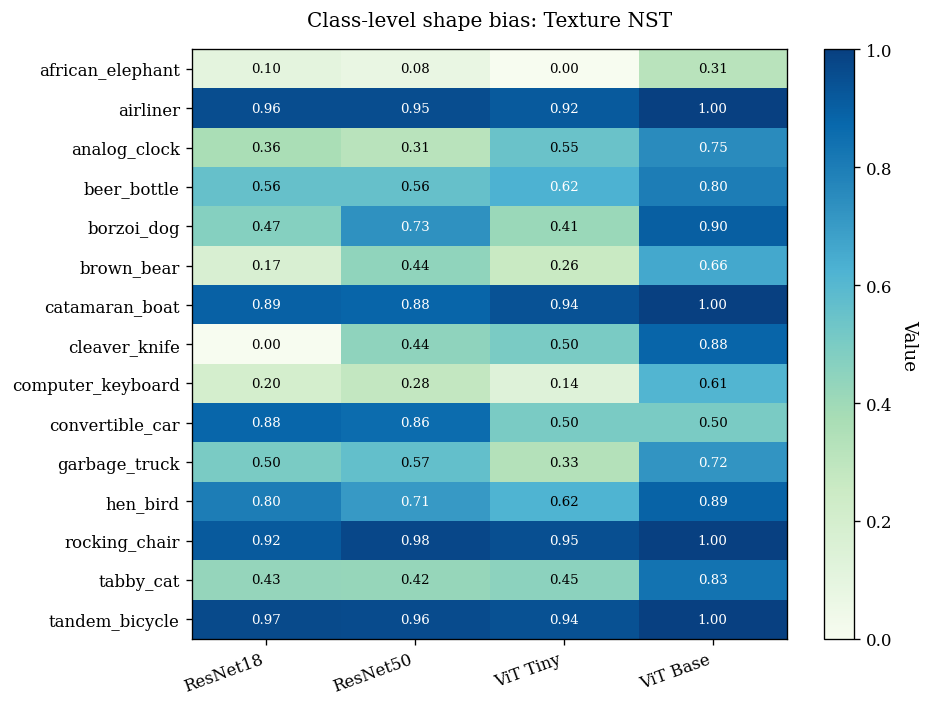

Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/figure_class_heatmap_texture_nst_annotated.png


PosixPath('/data/local/rgaisina/experiments_final/eval_results_1/figures/figure_class_heatmap_texture_nst_annotated.png')

In [15]:
condition_to_plot = 'texture_nst'  # change this manually

subset = summary_class[summary_class['condition'] == condition_to_plot].copy()
pivot = subset.pivot(index='shape_name', columns='model_display', values='shape_bias_top1')
pivot = pivot.reindex(columns=[MODEL_DISPLAY[m] for m in MODEL_ORDER]).sort_index()

fig_h = max(6, 0.32 * len(pivot))
fig, ax = heatmap_with_values(
    pivot,
    title=f"Class-level shape bias: {CONDITION_DISPLAY[condition_to_plot]}",
    figsize=(8, fig_h),
    vmin=0,
    vmax=1,
    cmap='GnBu',
    value_fmt='.2f',
    rotate_x=20,
)

plt.show()
save_figure(fig, f'figure_class_heatmap_{condition_to_plot}_annotated.png')

## 19. Optional confusion-style matrix with textures

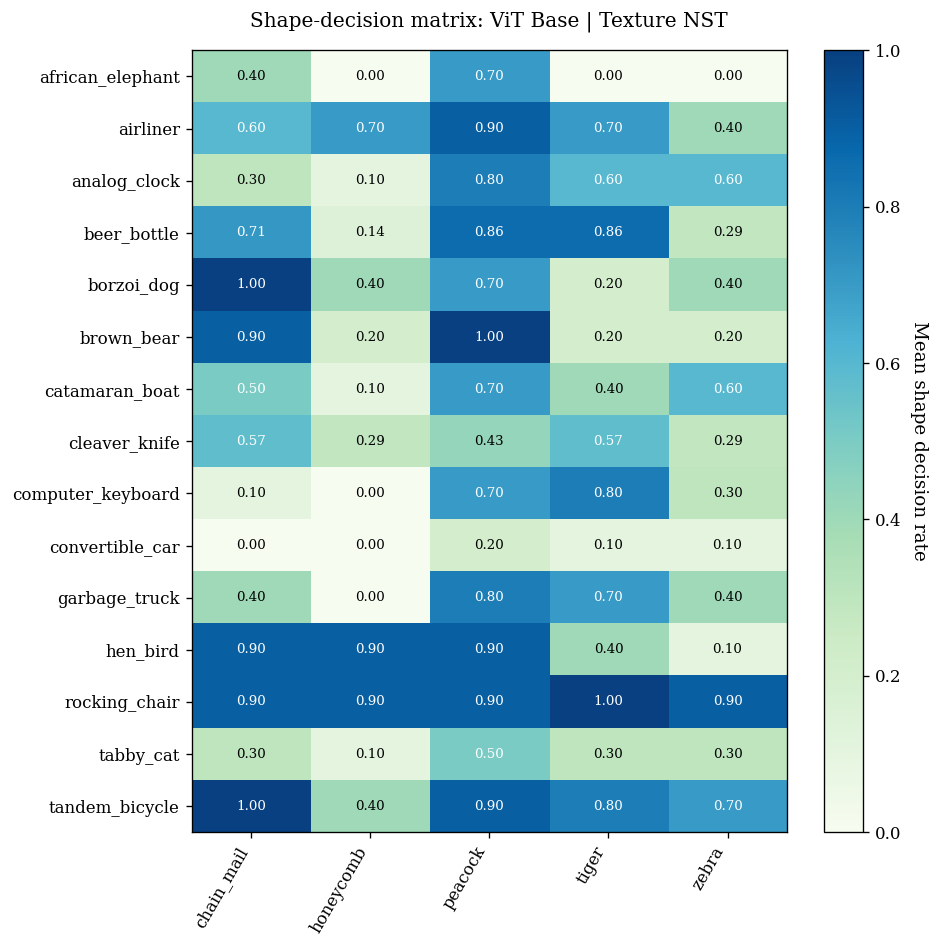

Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/figure_shape_decision_matrix_vit_base_texture_nst.png


In [17]:
model_to_plot = 'vit_base'
condition_to_plot = 'texture_nst'  # change this manually if needed

subset = data[(data['model'] == model_to_plot) & (data['condition'] == condition_to_plot)].copy()

if {'shape_name', 'texture_name', 'decision_top1'}.issubset(subset.columns):
    subset['is_shape_decision'] = (subset['decision_top1'] == 'shape').astype(float)
    matrix = subset.pivot_table(
        index='shape_name',
        columns='texture_name',
        values='is_shape_decision',
        aggfunc='mean',
    ).sort_index().sort_index(axis=1)

    fig_w = max(8, 0.35 * len(matrix.columns))
    fig_h = max(8, 0.30 * len(matrix.index))
    fig, ax = heatmap_with_values(
        matrix,
        title=f"Shape-decision matrix: {MODEL_DISPLAY[model_to_plot]} | {CONDITION_DISPLAY[condition_to_plot]}",
        figsize=(fig_w, fig_h),
        vmin=0,
        vmax=1,
        cmap='GnBu',
        value_fmt='.2f',
        rotate_x=60,
    )
    cbar = ax.images[0].colorbar
    cbar.ax.set_ylabel('Mean shape decision rate', rotation=270, labelpad=16)

    plt.show()
    save_figure(fig, f'figure_shape_decision_matrix_{model_to_plot}_{condition_to_plot}.png')
else:
    print('Required columns not found for confusion-style matrix.')

## 20. Save all class heatmaps automatically

In [18]:
for condition in [c for c in CONDITION_ORDER if c != 'original']:
    subset = summary_class[summary_class['condition'] == condition].copy()
    pivot = subset.pivot(index='shape_name', columns='model_display', values='shape_bias_top1')
    pivot = pivot.reindex(columns=[MODEL_DISPLAY[m] for m in MODEL_ORDER]).sort_index()

    fig_h = max(6, 0.32 * len(pivot))
    fig, ax = heatmap_with_values(
        pivot,
        title=f"Class-level shape bias: {CONDITION_DISPLAY[condition]}",
        figsize=(8, fig_h),
        vmin=0,
        vmax=1,
        cmap='GnBu',
        value_fmt='.2f',
        rotate_x=20,
    )
    save_figure(fig, f'figure_class_heatmap_{condition}_annotated.png')
    plt.close(fig)

print('Saved all class heatmaps.')

Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/figure_class_heatmap_texture_only_annotated.png
Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/figure_class_heatmap_texture_plus_edges_annotated.png
Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/figure_class_heatmap_texture_adain_annotated.png
Saved: /data/local/rgaisina/experiments_final/eval_results_1/figures/figure_class_heatmap_texture_nst_annotated.png
Saved all class heatmaps.


## 21. Thesis summary table

In [19]:
thesis_cols = [
    'model_display',
    'condition_display',
    'shape_bias_top1',
    'shape_in_top5_rate',
    'texture_top1_pct',
    'mean_prob_gap_shape_minus_texture',
]
if HAS_PARENT_METRICS:
    thesis_cols += ['parent_top1_match', 'parent_top5_match', 'parent_prob_mass']

thesis_table = (
    summary_main[thesis_cols]
    .copy()
    .round(3)
)

display(thesis_table)
thesis_table.to_csv(TABLES_DIR / 'thesis_summary_table.csv', index=False)
print('Saved thesis summary table')

,model_display,condition_display,shape_bias_top1,shape_in_top5_rate,texture_top1_pct,mean_prob_gap_shape_minus_texture,parent_top1_match,parent_top5_match,parent_prob_mass
0,ResNet18,Texture AdaIN,0.502,0.381,0.167,0.007,0.262,0.462,0.211
1,ResNet18,Texture NST,0.590,0.554,0.193,0.059,0.378,0.631,0.316
2,ResNet18,Texture Only,0.042,0.122,0.799,-0.686,0.061,0.193,0.048
3,ResNet18,Texture + Edges,0.336,0.410,0.415,-0.180,0.286,0.501,0.244
4,ResNet50,Texture AdaIN,0.668,0.412,0.104,0.090,0.306,0.536,0.253
5,ResNet50,Texture NST,0.634,0.588,0.179,0.125,0.426,0.669,0.384
6,ResNet50,Texture Only,0.072,0.175,0.782,-0.696,0.078,0.253,0.068
7,ResNet50,Texture + Edges,0.372,0.478,0.449,-0.171,0.356,0.572,0.312
8,ViT Base,Texture AdaIN,0.867,0.710,0.053,0.227,0.528,0.792,0.448
9,ViT Base,Texture NST,0.803,0.818,0.121,0.300,0.657,0.865,0.572


Saved thesis summary table
